In [31]:
import json

import gc_utils
import gizmo_analysis as gizmo
import h5py
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut
from scipy.signal import savgol_filter
from sklearn import cluster as cl

In [86]:
sim = "m12i"
snap_lim = 50
snap_step = 10

# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"

snap_file = fire_dir + "/snapshot_times.txt"
snap_data = pd.read_table(snap_file, comment="#", header=None, sep=r"\s+")
snap_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

time_lst_full = snap_data["index"]

sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)

In [87]:
snap_lst = np.arange(snap_lim, 600 + snap_step, snap_step)

time_lst = []
for snap in snap_lst:
    time = snap_data[snap_data["index"] == snap]["time_Gyr"].values[0]
    time_lst.append(time)

time_lst = np.array(time_lst)

In [89]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i"]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

plot_dict = {}
for i, sim in enumerate(sim_lst):
    main_halo = sim_codes[sim]["halo"]
    halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")

    plot_dict[sim] = {}

    t = []
    star_rad_50 = []
    star_rad_90 = []
    for snap in snap_lst:
        print(snap)
        halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
        halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]
        # halo_cidx = halt["catalog.index"][halo_tidx]

        # hal_cat = halo.io.IO.read_catalogs("index", snap, fire_dir)
        t.append(halt["star.mass"][halo_tidx])
        star_rad_50.append(halt["star.radius.50"][halo_tidx])
        star_rad_90.append(halt["star.radius.90"][halo_tidx])

    t = np.array(t)
    t_norm = t / t[-1]

    t_norm = savgol_filter(t_norm, window_length=50, polyorder=3)
    t_norm_diff = np.diff(t_norm)

    plot_dict[sim]["t"] = t
    plot_dict[sim]["t_norm"] = t_norm
    plot_dict[sim]["t_norm_diff"] = t_norm_diff

    plot_dict[sim]["star_rad_50"] = star_rad_50
    plot_dict[sim]["star_rad_90"] = star_rad_90

Retrieving Halo Tree.....................: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [06:32<00:00, 392.39s/it]


In [90]:
def get_labels(var):
    if var == "t":
        label = "stellar mass"
    elif var == "t_norm":
        label = "stellar mass normalised by stellar mass at z=0"
    elif var == "t_norm_diff":
        label = "stellar mass growth"
    elif var == "star_rad_50":
        label = r"stellar radius containing 50% of stellar mass"
    elif var == "star_rad_90":
        label = r"stellar radius containing 90% of stellar mass"
    return label

In [101]:
def plt_func(var, sim_lst, plot_dict, time_lst, log=False):
    for i, sim in enumerate(sim_lst):
        var_plt = plot_dict[sim][var]

        if var == "t_norm_diff":
            time_plt = time_lst[1:]
        else:
            time_plt = time_lst

        plt.plot(time_plt, var_plt, c=colors[i], label=sim)

        if log:
            plt.yscale("log")

        plt.xlabel("time (Gyr)")
        plt.ylabel(get_labels(var))

    plt.legend()

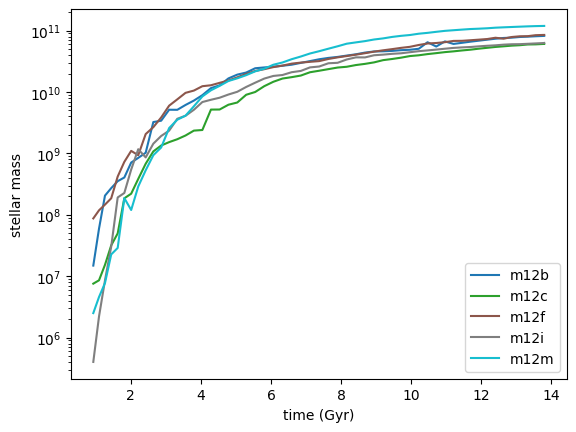

In [102]:
plt_func("t", sim_lst, plot_dict, time_lst, log=True)

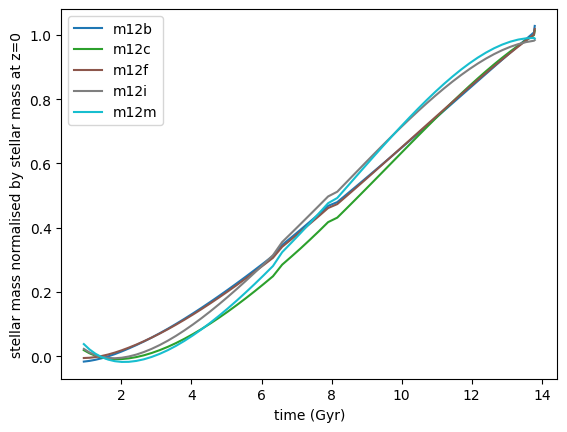

In [94]:
plt_func("t_norm", sim_lst, plot_dict, time_lst)

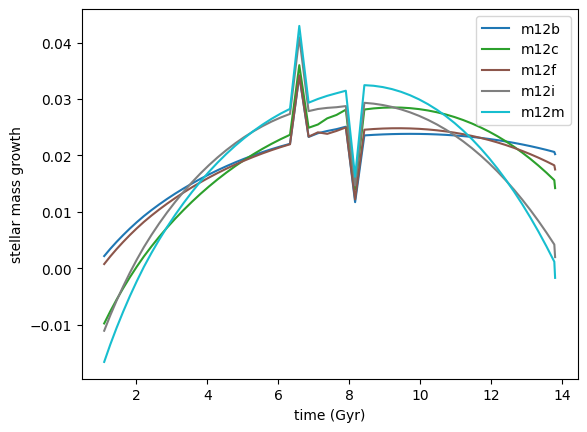

In [95]:
plt_func("t_norm_diff", sim_lst, plot_dict, time_lst)

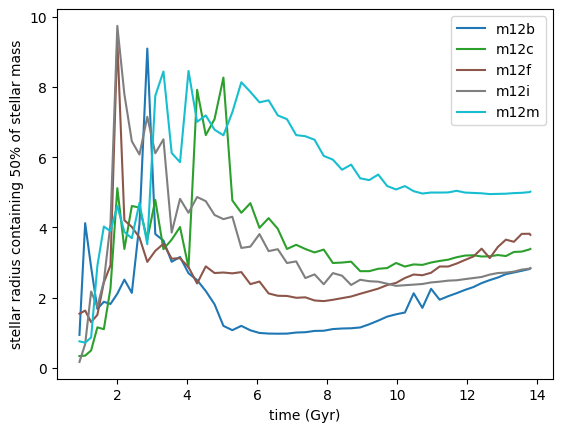

In [96]:
plt_func("star_rad_50", sim_lst, plot_dict, time_lst)

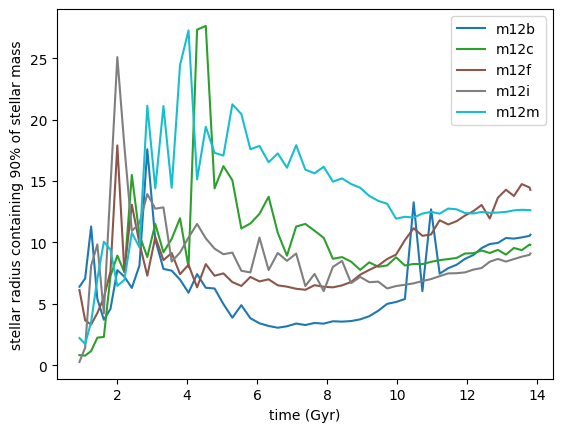

In [97]:
plt_func("star_rad_90", sim_lst, plot_dict, time_lst)

In [123]:
min_dict = {}
for sim in sim_lst:
    tim_msk = time_lst > 4.5
    min_rad = np.min(np.array(plot_dict[sim]["star_rad_90"])[tim_msk])
    msk = plot_dict[sim]["star_rad_90"] == min_rad
    min_dict[sim] = time_lst[msk]

In [124]:
min_dict

{'m12b': array([6.58906279]),
 'm12c': array([8.9418514]),
 'm12f': array([7.37627853]),
 'm12i': array([7.90065004]),
 'm12m': array([9.96532874])}